In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

from imblearn.over_sampling import SMOTE

print("All libraries imported successfully!")

df = pd.read_csv("../data/creditcard.csv")

print("Dataset Shape:", df.shape)


All libraries imported successfully!
Dataset Shape: (284807, 31)


In [2]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [4]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [5]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

In [6]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (227845, 30)
Testing data: (56962, 30)


In [7]:
from imblearn.pipeline import Pipeline

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

print("Logistic Regression pipeline created successfully!")

Logistic Regression pipeline created successfully!


In [8]:
lr_pipeline.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [9]:
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")

Predictions generated successfully!


In [10]:
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-Score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

Precision:

 0.057803468208092484
Recall: 0.9183673469387755
F1-Score: 0.10876132930513595
ROC-AUC: 0.9708434302252134


In [11]:
rf_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

print("Random Forest pipeline created successfully!")

Random Forest pipeline created successfully!


In [12]:
rf_pipeline.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [13]:
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest predictions generated successfully!")

Random Forest predictions generated successfully!


In [14]:
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

Precision: 0.8350515463917526
Recall: 0.826530612244898
F1-Score: 0.8307692307692308
ROC-AUC: 0.9644232605112952


In [15]:
rf_grid.fit(X_train, y_train)

print("GridSearchCV training completed!")

NameError: name 'rf_grid' is not defined

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

df = pd.read_csv("../data/creditcard.csv")

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Setup restored successfully!")

Setup restored successfully!


In [ ]:
rf_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("classifier", RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        n_estimators=50
    ))
])

rf_param_grid = {
    "classifier__max_depth": [10, None]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1
)

print("5-Fold GridSearchCV setup complete!")

5-Fold GridSearchCV setup complete!


In [ ]:
rf_grid.fit(X_tune, y_tune)

print("5-Fold GridSearchCV completed!")

Fitting 5 folds for each of 2 candidates, totalling 10 fits
5-Fold GridSearchCV completed!


In [ ]:
X_tune, _, y_tune, _ = train_test_split(
    X_train,
    y_train,
    train_size=20000,
    random_state=42,
    stratify=y_train
)

print("Tuning data:", X_tune.shape)
print("Fraud cases in tuning data:", y_tune.sum())

Tuning data: (20000, 30)
Fraud cases in tuning data: 35


In [ ]:
rf_grid.fit(X_tune, y_tune)

print("Fast GridSearchCV completed!")

Fitting 5 folds for each of 2 candidates, totalling 10 fits
Fast GridSearchCV completed!


In [ ]:
print("Best Parameters:", rf_grid.best_params_)
print("Best ROC-AUC Score:", rf_grid.best_score_)

Best Parameters: {'classifier__max_depth': 10}
Best ROC-AUC Score: 0.9707344996601195


In [ ]:
best_rf_model = rf_grid.best_estimator_

y_pred_rf_tuned = best_rf_model.predict(X_test)
y_prob_rf_tuned = best_rf_model.predict_proba(X_test)[:, 1]

print("Tuned Random Forest predictions generated successfully!")

Tuned Random Forest predictions generated successfully!


In [ ]:
print("Precision:", precision_score(y_test, y_pred_rf_tuned))
print("Recall:", recall_score(y_test, y_pred_rf_tuned))
print("F1-Score:", f1_score(y_test, y_pred_rf_tuned))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf_tuned))

Precision: 0.8315789473684211
Recall: 0.8061224489795918
F1-Score: 0.8186528497409327
ROC-AUC: 0.9524738760867318


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf_tuned)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[56848    16]
 [   19    79]]


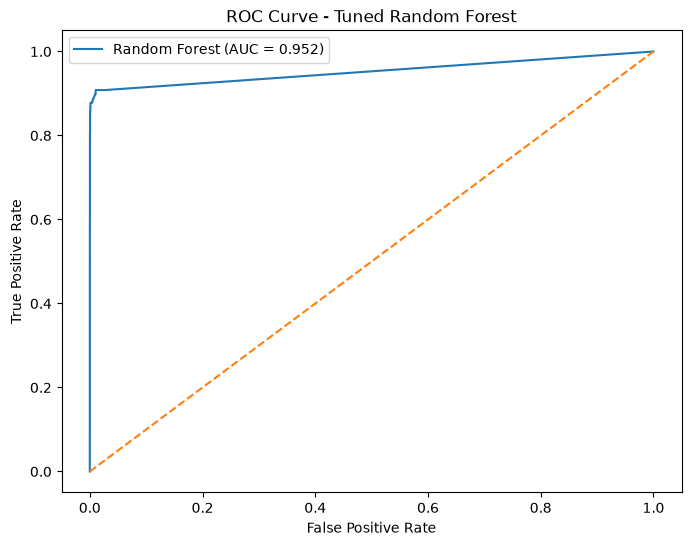

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf_tuned)

plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf_tuned):.3f})"
)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Random Forest")
plt.legend()
plt.show()

In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Tuned Random Forest"],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf_tuned)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf_tuned)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf_tuned)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf_tuned)
    ]
})

print(results)

                 Model  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression   0.057803  0.918367  0.108761  0.970843
1  Tuned Random Forest   0.831579  0.806122  0.818653  0.952474


In [ ]:
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression predictions restored successfully!")

Logistic Regression predictions restored successfully!


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

Class
0    284315
1       492
Name: count, dtype: int64


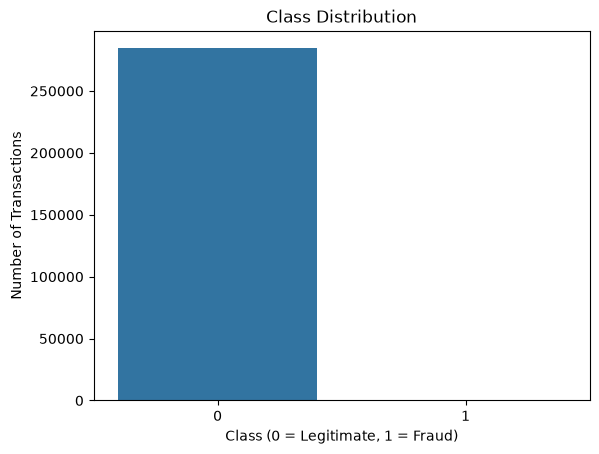

In [ ]:
print(df["Class"].value_counts())

sns.countplot(x="Class", data=df)

plt.title("Class Distribution")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()

In [ ]:
print("Best Parameters:", rf_grid.best_params_)
print("Best CV ROC-AUC:", rf_grid.best_score_)

Best Parameters: {'classifier__max_depth': 10}
Best CV ROC-AUC: 0.9707344996601195


In [ ]:
best_rf_model = rf_grid.best_estimator_

y_pred_rf_tuned = best_rf_model.predict(X_test)
y_prob_rf_tuned = best_rf_model.predict_proba(X_test)[:, 1]

print("Tuned Random Forest predictions generated successfully!")

Tuned Random Forest predictions generated successfully!


In [ ]:
print("Precision:", precision_score(y_test, y_pred_rf_tuned))
print("Recall:", recall_score(y_test, y_pred_rf_tuned))
print("F1-Score:", f1_score(y_test, y_pred_rf_tuned))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf_tuned))

Precision: 0.8315789473684211
Recall: 0.8061224489795918
F1-Score: 0.8186528497409327
ROC-AUC: 0.9524739658102971


In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Tuned Random Forest"],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf_tuned)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf_tuned)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf_tuned)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf_tuned)
    ]
})

print(results)

                 Model  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression   0.057803  0.918367  0.108761  0.970843
1  Tuned Random Forest   0.831579  0.806122  0.818653  0.952474


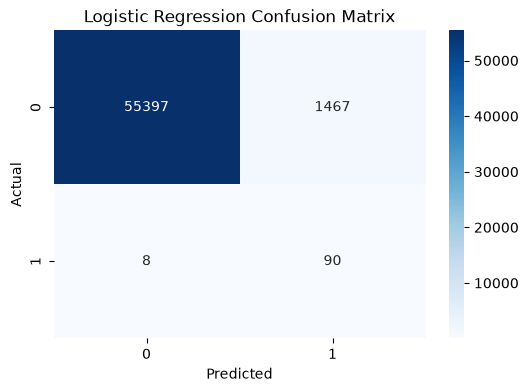

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf_tuned)

print("Tuned Random Forest Confusion Matrix:")
print(cm_rf)

Tuned Random Forest Confusion Matrix:
[[56848    16]
 [   19    79]]


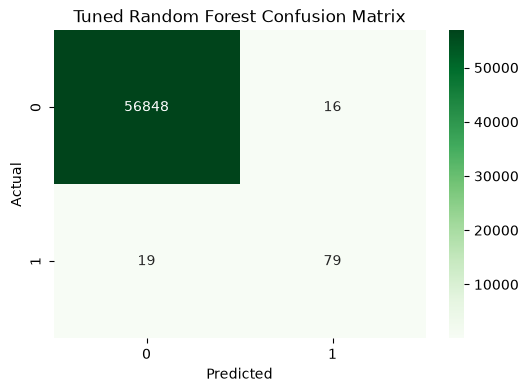

In [ ]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Tuned Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf_tuned)

print("ROC curve data prepared successfully!")

ROC curve data prepared successfully!


In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf_model.named_steps["classifier"].feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

   Feature  Importance
14     V14    0.338621
10     V10    0.129802
3       V3    0.102927
17     V17    0.085689
4       V4    0.084417
12     V12    0.071914
7       V7    0.042887
11     V11    0.032408
16     V16    0.025310
2       V2    0.022904


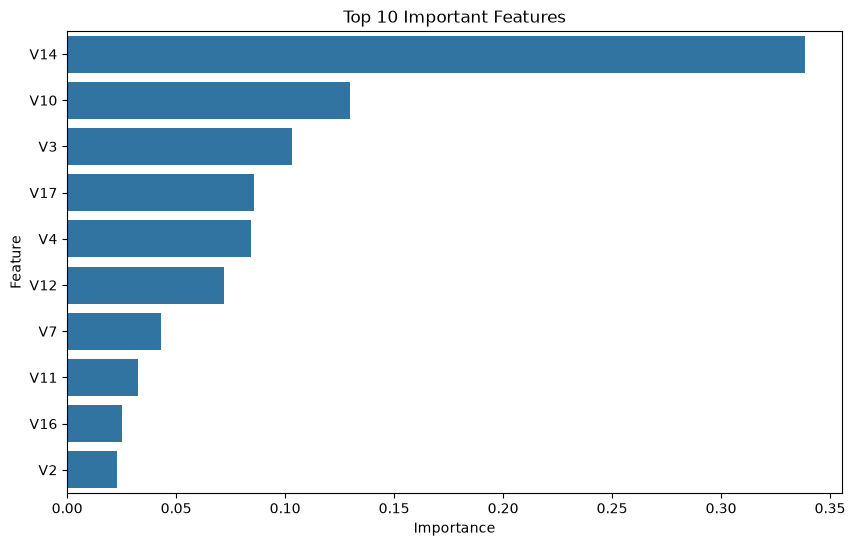

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
print("FRAUD DETECTION PROJECT COMPLETED")
print("-----------------------------------")

print("Dataset shape:", df.shape)
print("Total transactions:", len(df))
print("Fraudulent transactions:", int(df["Class"].sum()))
print("Legitimate transactions:", int((df["Class"] == 0).sum()))

print("\nModels trained:")
print("1. Logistic Regression")
print("2. Tuned Random Forest")

print("\nSMOTE was used inside the pipeline to handle class imbalance.")

print("\nModel evaluation focused on:")
print("Precision, Recall, F1 Score and ROC-AUC.")

print("\nConfusion matrices and ROC curve comparison were also generated.")

FRAUD DETECTION PROJECT COMPLETED
-----------------------------------
Dataset shape: (284807, 31)
Total transactions: 284807
Fraudulent transactions: 492
Legitimate transactions: 284315

Models trained:
1. Logistic Regression
2. Tuned Random Forest

SMOTE was used inside the pipeline to handle class imbalance.

Model evaluation focused on:
Precision, Recall, F1 Score and ROC-AUC.

Confusion matrices and ROC curve comparison were also generated.
